<a href="https://colab.research.google.com/github/brvndon266/MAE249_Soft_Robotics/blob/main/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

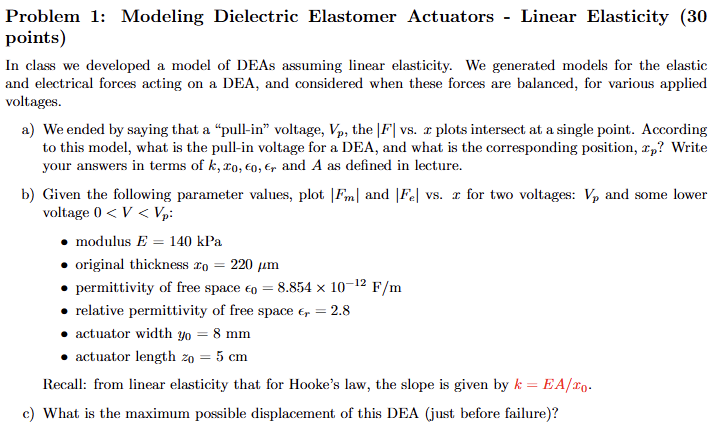

Problem 1 - Part B
---

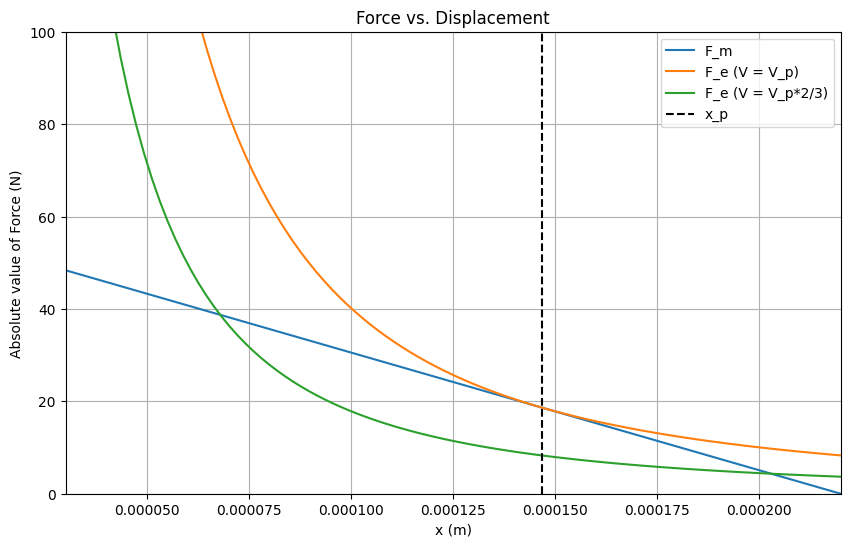

Pulldown voltage V_p = 8999.14 V
Stiffness k = 254545.45 N/m
Intersection point x_p = 1.47e-04 m


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1 b)
E = 140e3  # Young's Modulus, Pa
x_0 = 220e-6  # Original thickness, m
eps_0 = 8.854e-12  # Permissivity of free space, Farad/m
eps_r = 2.8  # Relative permissivity, dimensionless
y_0 = 8e-3  # Actuator width, m
z_0 = 5e-2  # Actuator length, m

A = y_0 * z_0  # Actuator area, m^2 (assumed constant for this problem (Hookean model))
k = E * A / x_0  # Stiffness of actuator, N/m

# For sake of plot visibility, plot over x = (3e-5, x_0)
n = 100
x_LL = 3e-5
x = np.linspace(x_LL, x_0, n)

V_p = np.sqrt((8 * k * x_0**3) / (27 * eps_0 * eps_r * A))  # Pulldown voltage, obtained from part a)
V_2 = V_p * 2/3  # Some voltage between V = 0 and V = V_p
x_p = x_0 * 2/3  # x where two curves intersect at V = V_p

# Initialize arrays
F_m = np.zeros(n)
F_e_V_p = np.zeros(n)
F_e_V_2 = np.zeros(n)

# Calculate forces
for i in range(n):
    F_m[i] = k * (x_0 - x[i])
    F_e_V_p[i] = (eps_0 * eps_r * A * V_p**2) / (2 * x[i]**2)
    F_e_V_2[i] = (eps_0 * eps_r * A * V_2**2) / (2 * x[i]**2)

# Create plot
plt.figure(figsize=(10, 6))
plt.plot(x, F_m, label='F_m')
plt.plot(x, F_e_V_p, label='F_e (V = V_p)')
plt.plot(x, F_e_V_2, label='F_e (V = V_p*2/3)')
plt.plot([x_p, x_p], [0, 100], 'k--', label='x_p')
plt.ylim([0, 100])
plt.xlim([x_LL, x_0])
plt.xlabel('x (m)')
plt.ylabel('Absolute value of Force (N)')
plt.legend()
plt.title('Force vs. Displacement')
plt.grid(True)
plt.show()

# Print some values for verification
print(f"Pulldown voltage V_p = {V_p:.2f} V")
print(f"Stiffness k = {k:.2f} N/m")
print(f"Intersection point x_p = {x_p:.2e} m")

Problem 2 - Part B
---

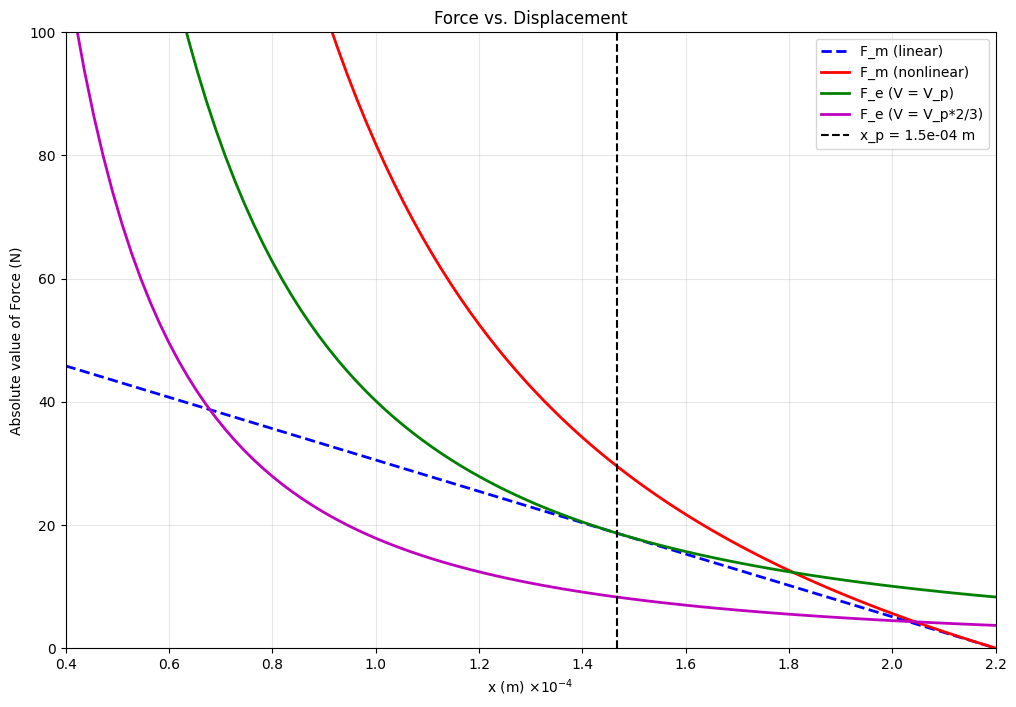

Pulldown voltage V_p = 8999.14 V
Stiffness k = 254545.45 N/m
Intersection point x_p = 1.47e-04 m
Original area A_0 = 4.00e-04 m²
Lambda range: 0.182 to 1.000
F_m_linear range: 45.82 to 0.00 N
F_m_nonlinear range: 561.27 to 0.00 N
F_e_V_p at x_min: 250.96 N, at x_max: 8.30 N


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1 b)
E = 140e3  # Young's Modulus, Pa
x_0 = 220e-6  # Original thickness, m (220 μm)
eps_0 = 8.854e-12  # Permissivity of free space, Farad/m
eps_r = 2.8  # Relative permissivity, dimensionless
y_0 = 8e-3  # Actuator width, m
z_0 = 5e-2  # Actuator length, m

A_0 = y_0 * z_0  # Original actuator area, m^2
k = E * A_0 / x_0  # Stiffness of actuator, N/m (linear model)

# Use the exact x-range from your plot: 0.4e-4 to 2.2e-4 m
n = 100
x_LL = 0.4e-4  # 40 μm
x_UL = 2.2e-4  # 220 μm
x = np.linspace(x_LL, x_UL, n)

V_p = np.sqrt((8 * k * x_0**3) / (27 * eps_0 * eps_r * A_0))  # Pulldown voltage
V_2 = V_p * 2/3  # Some voltage between V = 0 and V = V_p
x_p = x_0 * 2/3  # x where two curves intersect at V = V_p

# Calculate lambda = x/x_0 (stretch ratio in thickness direction)
lambda_vals = x / x_0

# Calculate areas - for incompressible material, area scales with 1/lambda
A_lambda = A_0 / lambda_vals  # A = A_0/lambda

# Calculate forces - use ABSOLUTE VALUES as in the MATLAB plot
# Linear mechanical force (Hookean) - absolute value
F_m_linear = np.abs(k * (x_0 - x))

# Nonlinear mechanical force: Fm = (A * E / 3) * (lambda - 1/lambda^2)
# Take absolute value and ensure positive force
F_m_nonlinear = np.abs((A_0 * E / 3) * (lambda_vals - 1/lambda_vals**2))

# Electrical forces (using original area A_0 as in linear case) - already positive
F_e_V_p = (eps_0 * eps_r * A_0 * V_p**2) / (2 * x**2)
F_e_V_2 = (eps_0 * eps_r * A_0 * V_2**2) / (2 * x**2)

# Create plot
plt.figure(figsize=(12, 8))
plt.plot(x, F_m_linear, 'b--', label='F_m (linear)', linewidth=2)
plt.plot(x, F_m_nonlinear, 'r-', label='F_m (nonlinear)', linewidth=2)
plt.plot(x, F_e_V_p, 'g-', label='F_e (V = V_p)', linewidth=2)
plt.plot(x, F_e_V_2, 'm-', label='F_e (V = V_p*2/3)', linewidth=2)
plt.axvline(x=x_p, color='k', linestyle='--', label=f'x_p = {x_p:.1e} m')

plt.ylim([0, 100])
plt.xlim([x_LL, x_UL])
plt.xlabel('x (m)')
plt.ylabel('Absolute value of Force (N)')
plt.legend()
plt.title('Force vs. Displacement')
plt.grid(True, alpha=0.3)

# Add x10^-4 notation to x-axis as in your plot
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e4:.1f}'))
plt.gca().set_xlabel('x (m) $\\times 10^{-4}$')

plt.show()

# Print values for comparison and debugging
print(f"Pulldown voltage V_p = {V_p:.2f} V")
print(f"Stiffness k = {k:.2f} N/m")
print(f"Intersection point x_p = {x_p:.2e} m")
print(f"Original area A_0 = {A_0:.2e} m²")
print(f"Lambda range: {lambda_vals[0]:.3f} to {lambda_vals[-1]:.3f}")
print(f"F_m_linear range: {F_m_linear[0]:.2f} to {F_m_linear[-1]:.2f} N")
print(f"F_m_nonlinear range: {F_m_nonlinear[0]:.2f} to {F_m_nonlinear[-1]:.2f} N")
print(f"F_e_V_p at x_min: {F_e_V_p[0]:.2f} N, at x_max: {F_e_V_p[-1]:.2f} N")

Problem 2 - Part C
---

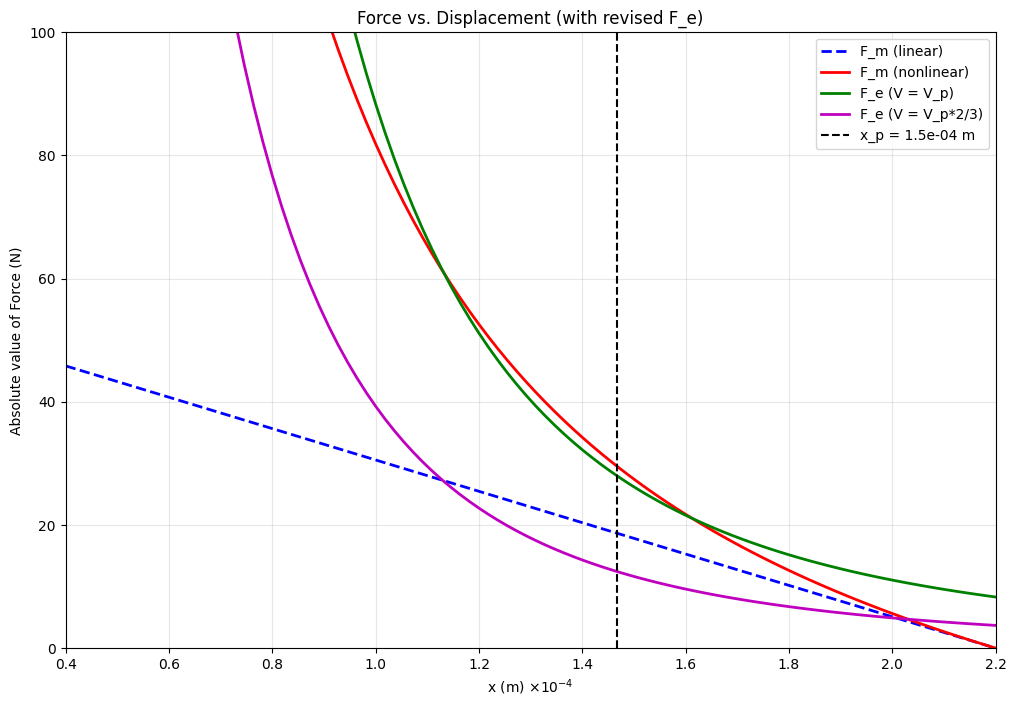

Pulldown voltage V_p = 8999.14 V
Stiffness k = 254545.45 N/m
Intersection point x_p = 1.47e-04 m
Original area A_0 = 4.00e-04 m²
Lambda range: 0.182 to 1.000
F_m_linear range: 45.82 to 0.00 N
F_m_nonlinear range: 561.27 to 0.00 N
F_e_V_p at x_min: 1380.30 N, at x_max: 8.30 N


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1 b)
E = 140e3  # Young's Modulus, Pa
x_0 = 220e-6  # Original thickness, m (220 μm)
eps_0 = 8.854e-12  # Permissivity of free space, Farad/m
eps_r = 2.8  # Relative permissivity, dimensionless
y_0 = 8e-3  # Actuator width, m
z_0 = 5e-2  # Actuator length, m

A_0 = y_0 * z_0  # Original actuator area, m^2
k = E * A_0 / x_0  # Stiffness of actuator, N/m (linear model)

# Use the exact x-range from your plot: 0.4e-4 to 2.2e-4 m
n = 100
x_LL = 0.4e-4  # 40 μm
x_UL = 2.2e-4  # 220 μm
x = np.linspace(x_LL, x_UL, n)

V_p = np.sqrt((8 * k * x_0**3) / (27 * eps_0 * eps_r * A_0))  # Pulldown voltage
V_2 = V_p * 2/3  # Some voltage between V = 0 and V = V_p
x_p = x_0 * 2/3  # x where two curves intersect at V = V_p

# Calculate lambda = x/x_0 (stretch ratio in thickness direction)
lambda_vals = x / x_0

# Calculate forces - use ABSOLUTE VALUES as in the MATLAB plot
# Linear mechanical force (Hookean) - absolute value
F_m_linear = np.abs(k * (x_0 - x))

# Nonlinear mechanical force: Fm = (A * E / 3) * (lambda - 1/lambda^2)
# Take absolute value and ensure positive force
F_m_nonlinear = np.abs((A_0 * E / 3) * (lambda_vals - 1/lambda_vals**2))

# REVISED Electrical forces: Fe = (eps_0 * eps_r * A_0 * V^2) / (2 * x_0^2 * lambda^3)
F_e_V_p = np.abs((eps_0 * eps_r * A_0 * V_p**2) / (2 * x_0**2 * lambda_vals**3))
F_e_V_2 = np.abs((eps_0 * eps_r * A_0 * V_2**2) / (2 * x_0**2 * lambda_vals**3))

# Create plot
plt.figure(figsize=(12, 8))
plt.plot(x, F_m_linear, 'b--', label='F_m (linear)', linewidth=2)
plt.plot(x, F_m_nonlinear, 'r-', label='F_m (nonlinear)', linewidth=2)
plt.plot(x, F_e_V_p, 'g-', label='F_e (V = V_p)', linewidth=2)
plt.plot(x, F_e_V_2, 'm-', label='F_e (V = V_p*2/3)', linewidth=2)
plt.axvline(x=x_p, color='k', linestyle='--', label=f'x_p = {x_p:.1e} m')

plt.ylim([0, 100])
plt.xlim([x_LL, x_UL])
plt.xlabel('x (m)')
plt.ylabel('Absolute value of Force (N)')
plt.legend()
plt.title('Force vs. Displacement (with revised F_e)')
plt.grid(True, alpha=0.3)

# Add x10^-4 notation to x-axis as in your plot
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e4:.1f}'))
plt.gca().set_xlabel('x (m) $\\times 10^{-4}$')

plt.show()

# Print values for comparison and debugging
print(f"Pulldown voltage V_p = {V_p:.2f} V")
print(f"Stiffness k = {k:.2f} N/m")
print(f"Intersection point x_p = {x_p:.2e} m")
print(f"Original area A_0 = {A_0:.2e} m²")
print(f"Lambda range: {lambda_vals[0]:.3f} to {lambda_vals[-1]:.3f}")
print(f"F_m_linear range: {F_m_linear[0]:.2f} to {F_m_linear[-1]:.2f} N")
print(f"F_m_nonlinear range: {F_m_nonlinear[0]:.2f} to {F_m_nonlinear[-1]:.2f} N")
print(f"F_e_V_p at x_min: {F_e_V_p[0]:.2f} N, at x_max: {F_e_V_p[-1]:.2f} N")

Problem 3 - Part B
---

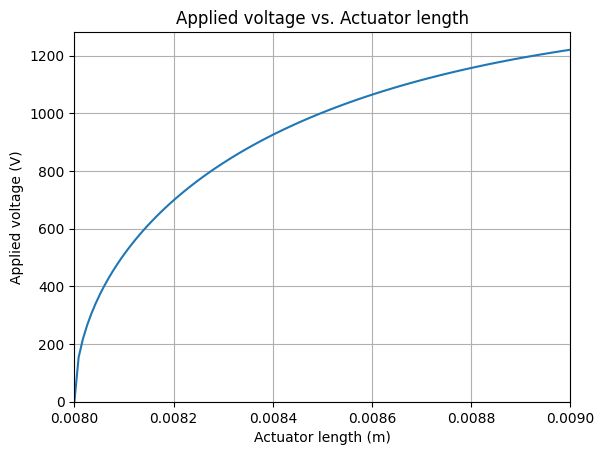

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 3 b )
E = 140e3  # Young's Modulus, Pa
t_0 = 220e-6  # Initial thickness of the actuator, m
eps_0 = 8.854e-12  # Permissivity of free space, Farad/m
eps_r = 2.8  # Relative permissivity, dimensionless
L_0 = 8e-3  # Initial length of actuator, m
R_0 = 3e-3  # Initial radius of actuator, m
n = 7  # Number of capacitor layers

x_0 = t_0 / 7  # Initial thickness of each capacitor layer

numpoints = 100  # Number of points for plotting
L_max = 9e-3  # Max L for plotting
lambda_min = (L_0 / L_max) ** 2  # min lambda for plotting; note that larger L = smaller lambda

lambda_vals = np.linspace(lambda_min, 1, numpoints)

U = np.zeros(numpoints)
L_vals = np.zeros(numpoints)

for i in range(numpoints):
    U[i] = np.sqrt((2 * E * x_0 ** 2 * lambda_vals[i] ** 3) / (3 * eps_0 * eps_r) * abs((lambda_vals[i] - 1 / (lambda_vals[i] ** 2))))
    L_vals[i] = L_0 / np.sqrt(lambda_vals[i])

plt.figure()
plt.plot(L_vals, U)
plt.xlabel('Actuator length (m)')
plt.ylabel('Applied voltage (V)')
plt.title('Applied voltage vs. Actuator length')
plt.grid(True)
plt.xlim(8e-3, 9e-3)
plt.ylim(bottom=0)

plt.show()

Problem 3 - Part C
---


In [12]:
import numpy as np

# --- Given parameters ---
E = 140e3           # Pa
t0 = 220e-6         # m
eps0 = 8.854e-12    # F/m
epsr = 2.8
L0 = 8e-3           # m
n = 7
x0 = t0 / n         # Initial thickness of each capacitor layer

# --- Desired elongation ---
delta_L = 1e-3      # 1 mm extension
L = L0 + delta_L    # Final length

# --- Calculate lambda ---
lambda_val = (L0 / L)**2  # Note: lambda = (L0/L)^2 for extension

# --- Voltage Formula ---
def V_required(lambda_val):
    term = (2 * E * x0**2 * lambda_val**3) / (3 * eps0 * epsr) * abs((lambda_val - 1/(lambda_val**2)))
    if term < 0:
        raise ValueError("Negative value under square root")
    return np.sqrt(term)

# --- Compute voltage ---
V = V_required(lambda_val)

# --- Display result ---
print(f"Initial length L0 = {L0*1e3:.1f} mm")
print(f"Final length L = {L*1e3:.1f} mm")
print(f"Elongation ΔL = {delta_L*1e3:.1f} mm")
print(f"Lambda = {lambda_val:.4f}")
print(f"Required applied voltage = {V:.2f} V ({V/1000:.2f} kV)")

Initial length L0 = 8.0 mm
Final length L = 9.0 mm
Elongation ΔL = 1.0 mm
Lambda = 0.7901
Required applied voltage = 1220.20 V (1.22 kV)


Problem 3 - Part D
---

In [11]:
import sympy as sp

# Problem 3 d )
E = 140e3  # Young's Modulus, Pa
t_0 = 220e-6  # Initial thickness of the actuator, m
eps_0 = 8.854e-12  # Permissivity of free space, Farad/m
eps_r = 2.8  # Relative permissivity, dimensionless
L_0 = 8e-3  # Initial length of actuator, m
R_0 = 3e-3  # Initial radius of actuator, m
n = 7  # Number of capacitor layers

x_0 = t_0 / 7  # Initial thickness of each capacitor layer

# Define symbolic variables
lambda_sym, U_sym = sp.symbols('lambda U')

# Define equations
force_eq = sp.Eq(E/3*(1/lambda_sym**2 - lambda_sym), (eps_0*eps_r*U_sym**2)/(2*x_0**2*lambda_sym**3))
force_deriv_eq = sp.Eq(E/3*(-2/lambda_sym**3 - 1), -(3*eps_0*eps_r*U_sym**2)/(2*x_0**2*lambda_sym**4))

# Solve the system of equations
solutions = sp.solve([force_eq, force_deriv_eq], [lambda_sym, U_sym])

# Extract solutions
sol_lambda, sol_U = solutions[0]  # Get the first solution

print(f"Lambda solution: {sol_lambda}")
print(f"U solution: {abs(sol_U)} V")

Lambda solution: 0.629960524947437
U solution: 1325.50556201050 V
